In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**1. Dataset**

In [ ]:
DP = pd.read_csv('/content/sample_data/database_cleaned.csv')
OUT_DIR = "figures"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
# Matplotlib / seaborn styling
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.autolayout"] = True

In [ ]:
date_cols = ["Declaration Date", "Start Date", "End Date", "Close Date"]
df = pd.read_csv(DP, dtype={"State": "string", "Disaster Type": "string"}, parse_dates=date_cols)

In [72]:
# Year/Month fields for time-based trends
df["year"] = df["Declaration Date"].dt.year
df["month"] = df["Declaration Date"].dt.month
df["month_name"] = df["Declaration Date"].dt.month_name()

In [73]:
# Event duration (in days) from Start -> End
df["duration_days"] = (df["End Date"] - df["Start Date"]).dt.days

# Time to close (in days) from End -> Close (if both present)
df["time_to_close_days"] = (df["Close Date"] - df["End Date"]).dt.days

# Helper: a safe label map for booleans
def blabel(x):
    if pd.isna(x):
        return "Unknown"
    return "Yes" if bool(x) else "No"

**2. Natural Disasters Declarations**

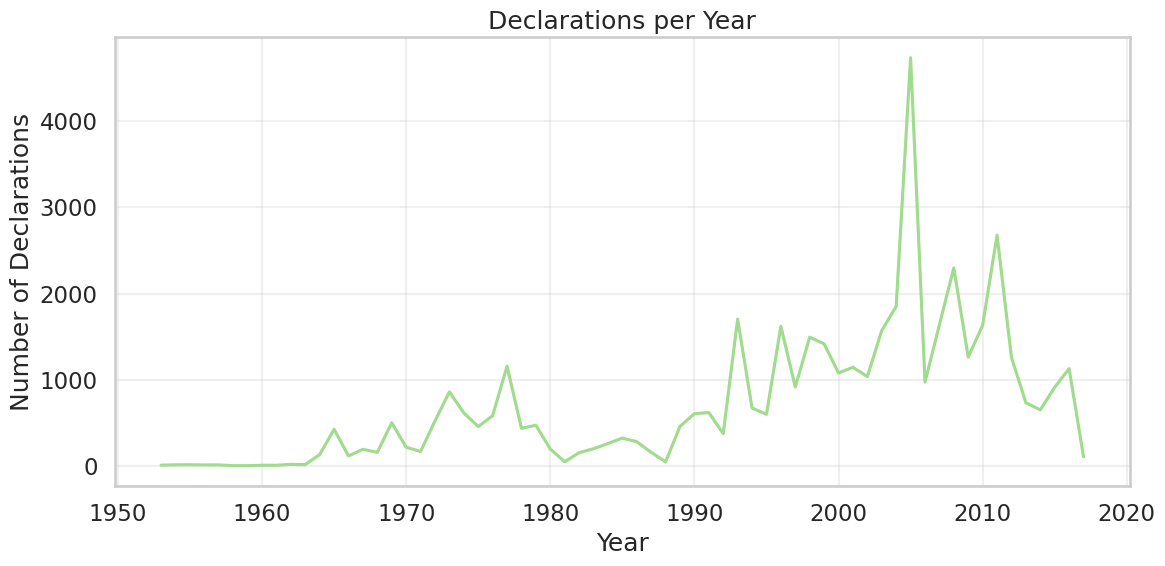

In [ ]:
counts_year = df.groupby("year", dropna=True).size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(data=counts_year, x="year", y="count", ax=ax, color="#a0db8e")
ax.set_title("Declarations per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Declarations")
ax.grid(True, alpha=0.3)
plt.show()

**3. Types of Disasters**

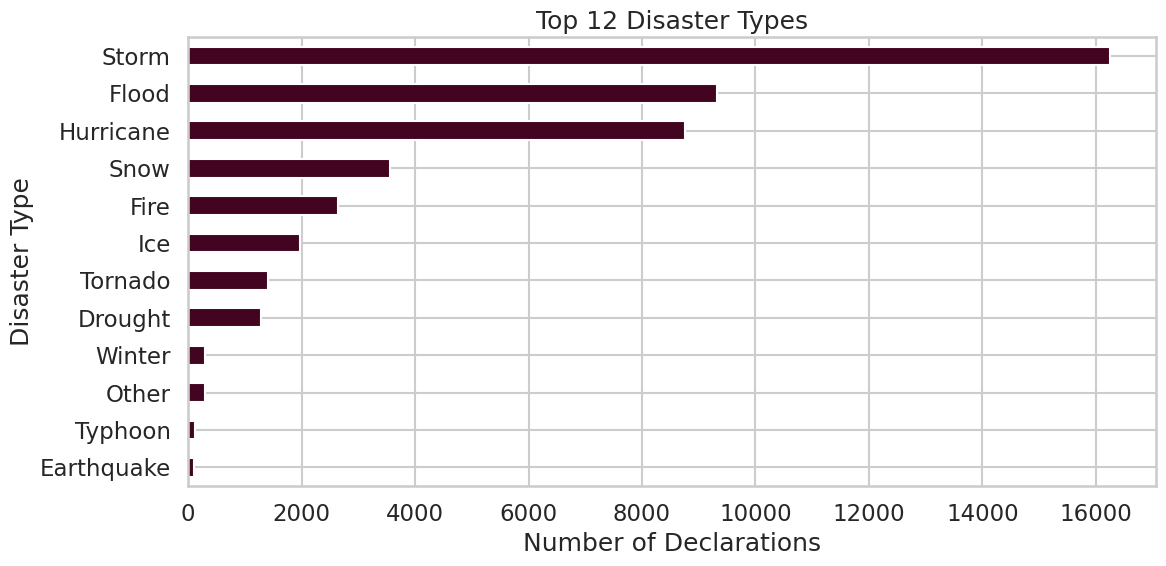

In [75]:
type_counts = df["Disaster Type"].value_counts().head(12).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(12,6))
type_counts.plot(kind="barh", color="#420420", ax=ax)
ax.set_title("Top 12 Disaster Types")
ax.set_xlabel("Number of Declarations")
ax.set_ylabel("Disaster Type")
plt.show()

**4. Seasonality Check**

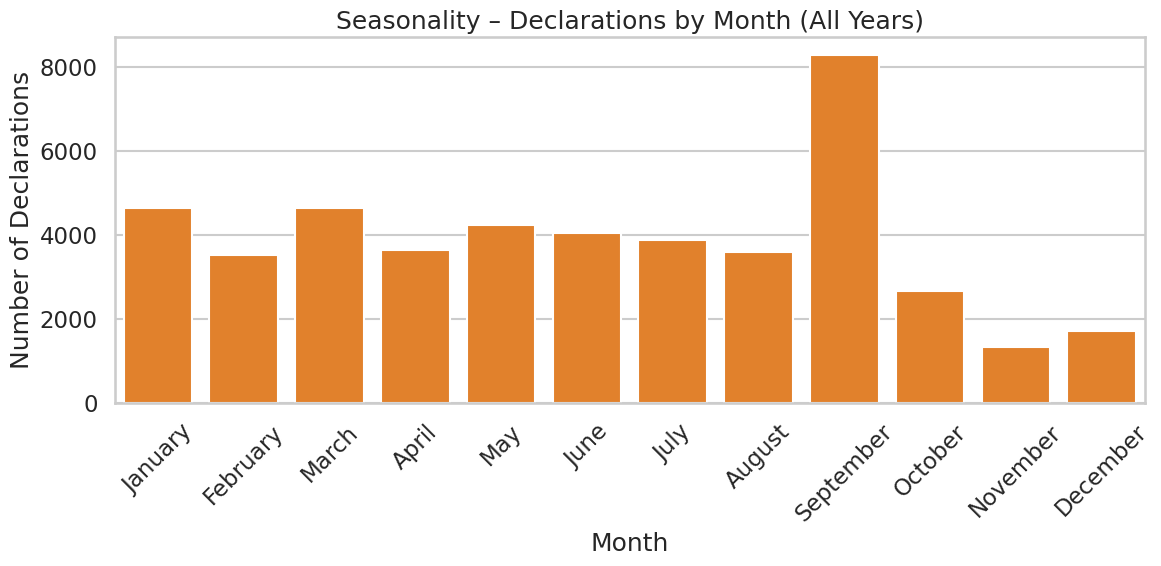

In [76]:
month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
month_counts = (df.groupby("month_name").size()
                  .reindex(month_order)
                  .reset_index(name="count"))
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(data=month_counts, x="month_name", y="count", color="#ff7f0e", ax=ax)
ax.set_title("Seasonality – Declarations by Month (All Years)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Declarations")
ax.tick_params(axis='x', rotation=45)
plt.show()

**5. Interactive Trend Aanlysis**

In [77]:
yearly_counts = df.groupby("month", dropna=True).size().reset_index(name="count")
yearly_counts["rolling_avg_3yr"] = yearly_counts["count"].rolling(window=3, center=True).mean()
print(yearly_counts.head())
print(yearly_counts.tail())

   month  count  rolling_avg_3yr
0      1   4630              NaN
1      2   3526      4263.000000
2      3   4633      3931.666667
3      4   3636      4166.666667
4      5   4231      3969.333333
    month  count  rolling_avg_3yr
7       8   3602      5255.333333
8       9   8281      4852.000000
9      10   2673      4098.333333
10     11   1341      1907.333333
11     12   1708              NaN


In [78]:
import plotly.express as px

# Prepare data
yearly_counts = df.groupby('year').size().reset_index(name='counts')
yearly_counts['rolling_avg'] = yearly_counts['counts'].rolling(window=3).mean()

fig = px.line(yearly_counts, x='year', y=['counts', 'rolling_avg'],
              title='Interactive Yearly Disaster Trends',
              labels={'value': 'Number of Disasters', 'year': 'Year'})
fig.update_layout(hovermode="x unified")
fig.show()


**6. Hurricane**

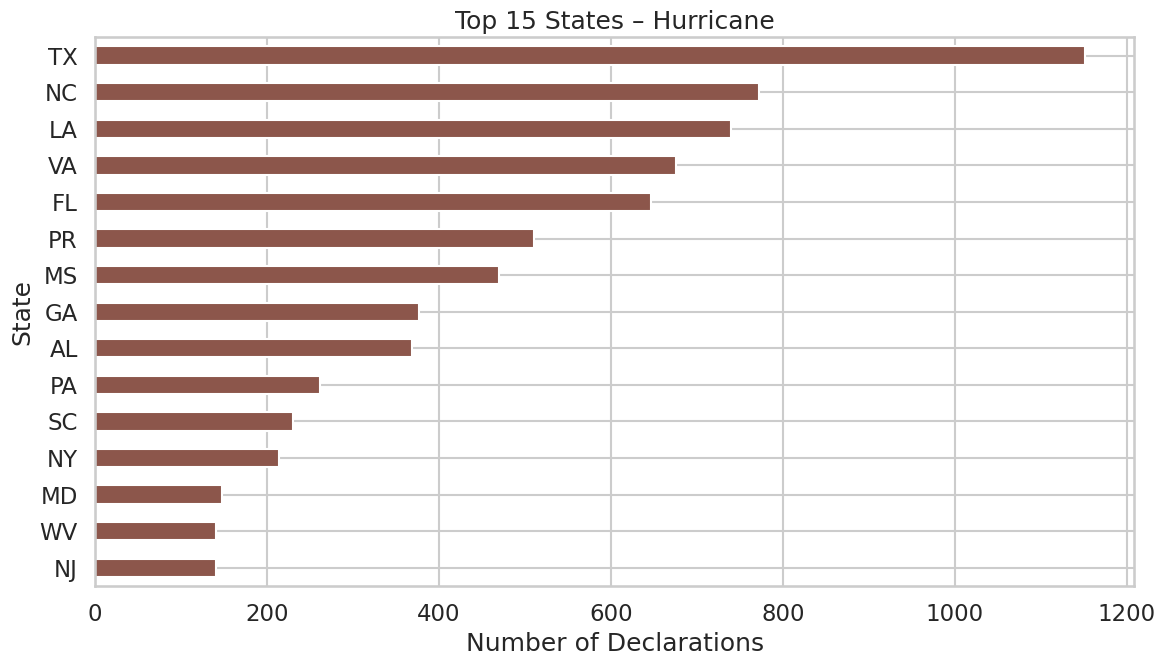

In [79]:

# Change this to any type found in your data (e.g., "Hurricane", "Flood", "Storm")
SELECTED_TYPE = "Hurricane"
subset = df[df["Disaster Type"] == SELECTED_TYPE]
st_counts = subset["State"].value_counts().head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12,7))
st_counts.plot(kind="barh", color="#8c564b", ax=ax)
ax.set_title(f"Top 15 States – {SELECTED_TYPE}")
ax.set_xlabel("Number of Declarations")
ax.set_ylabel("State")
fig.savefig(os.path.join(OUT_DIR, f"06_top_states_{SELECTED_TYPE.lower()}.png"), dpi=150)
plt.show()

**7. Relationship and Correlation**

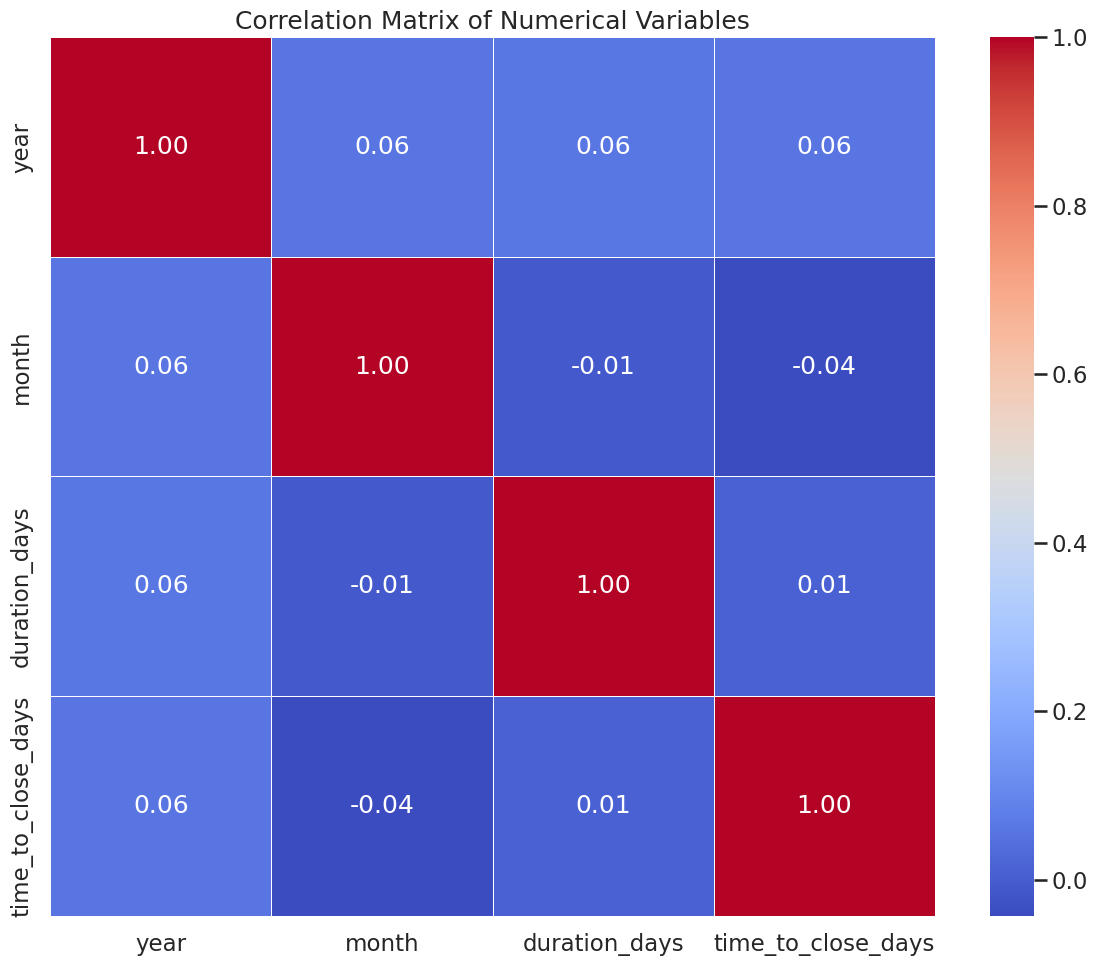

In [80]:
numeric_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.



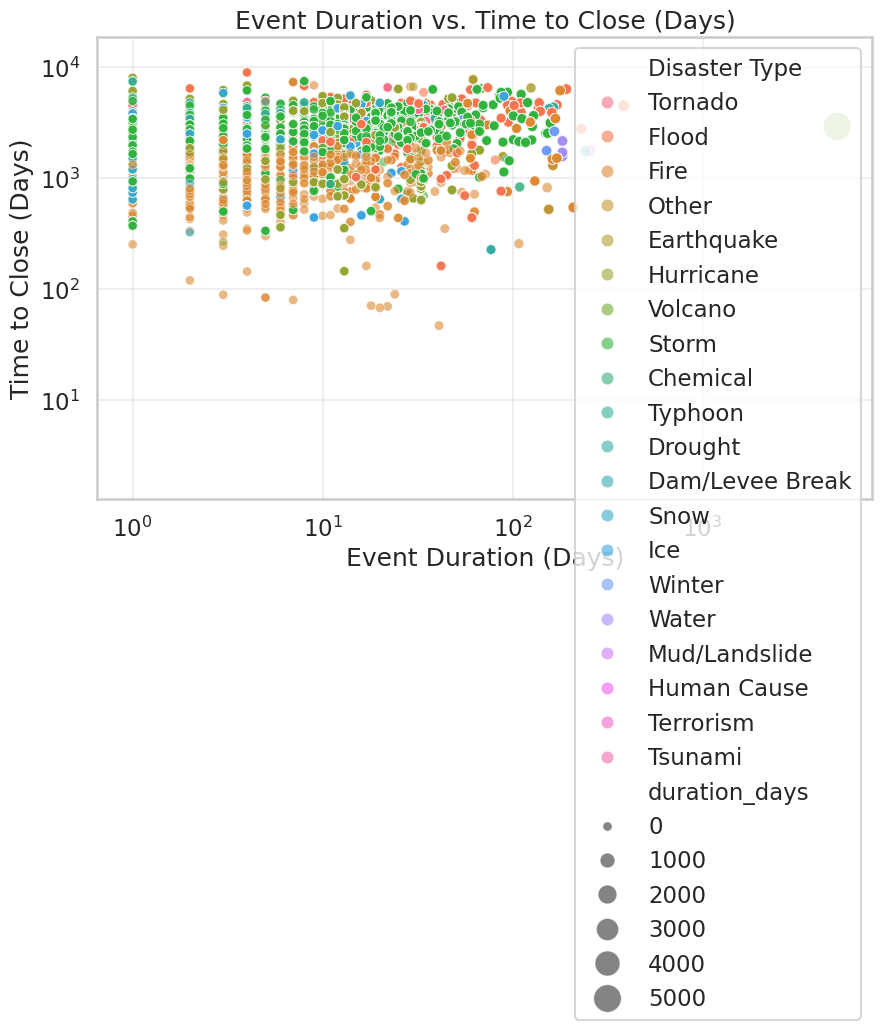

In [81]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='duration_days', y='time_to_close_days', alpha=0.6, hue='Disaster Type', size='duration_days', sizes=(20, 400))
plt.title('Event Duration vs. Time to Close (Days)')
plt.xlabel('Event Duration (Days)')
plt.ylabel('Time to Close (Days)')
plt.xscale('log') # Log scale for better visualization of skewed data
plt.yscale('log') # Log scale for better visualization of skewed data
plt.grid(True, alpha=0.3)
plt.show()

**8. Time Period**

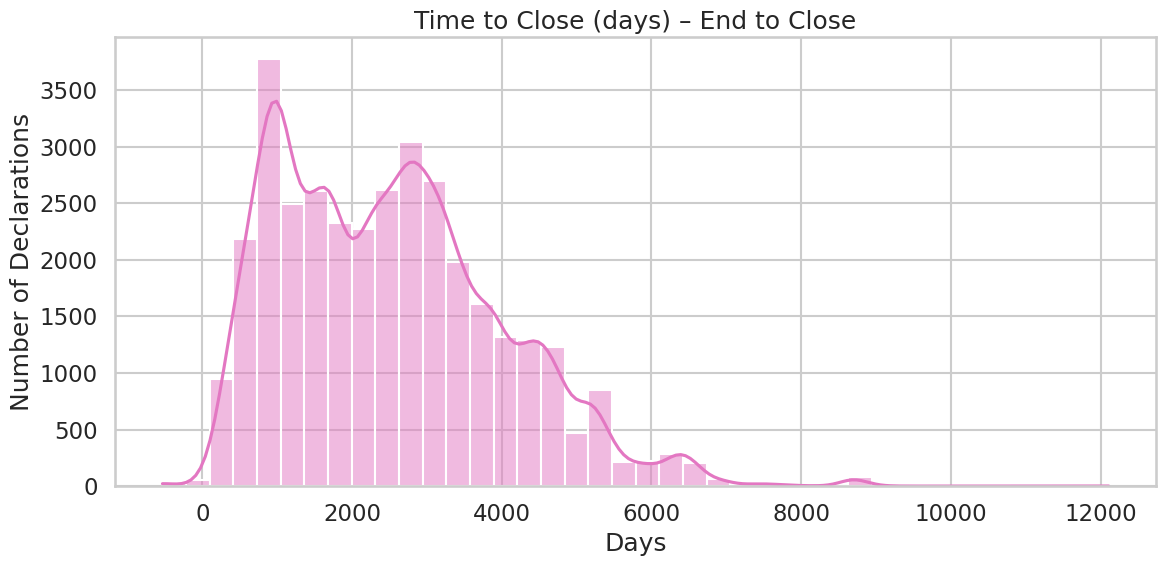

In [82]:
ttc = df["time_to_close_days"].dropna()
fig, ax = plt.subplots(figsize=(12,6))
sns.histplot(ttc, bins=40, kde=True, color="#e377c2", ax=ax)
ax.set_title("Time to Close (days) – End to Close")
ax.set_xlabel("Days"); ax.set_ylabel("Number of Declarations")
fig.savefig(os.path.join(OUT_DIR, "09_time_to_close_hist.png"), dpi=150)
plt.show()

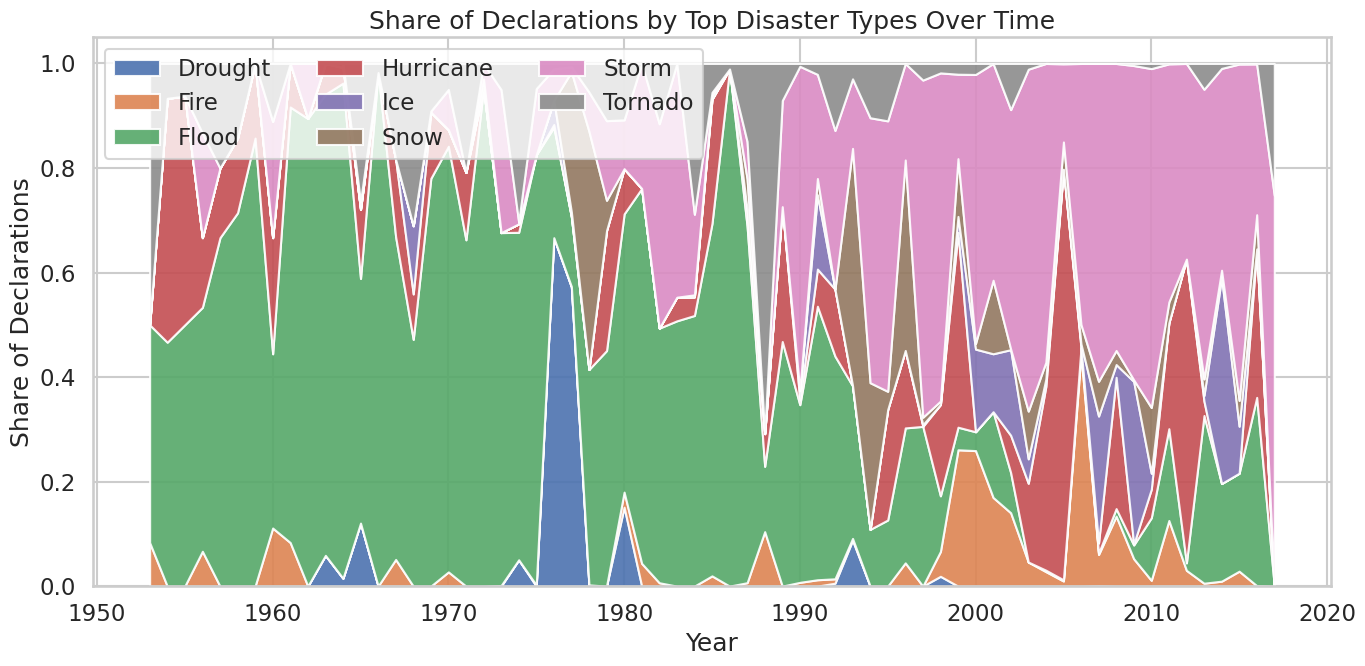

In [83]:
mix = (df[df["Disaster Type"].isin(top_types)]
       .groupby(["year","Disaster Type"]).size()
       .reset_index(name="count"))
total_per_year = mix.groupby("year")["count"].transform("sum")
mix["share"] = mix["count"] / total_per_year

# Pivot to wide for stacked area
mix_w = mix.pivot(index="year", columns="Disaster Type", values="share").fillna(0).sort_index()
fig, ax = plt.subplots(figsize=(14,7))
ax.stackplot(mix_w.index, mix_w.T, labels=mix_w.columns, alpha=0.9)
ax.set_title("Share of Declarations by Top Disaster Types Over Time")
ax.set_xlabel("Year"); ax.set_ylabel("Share of Declarations")
ax.legend(loc="upper left", ncols=3)
fig.savefig(os.path.join(OUT_DIR, "10_stacked_area_mix.png"), dpi=150)
plt.show()
